# 📌 Extracción – Puntos a Considerar

Has sido contratado como **asistente de análisis de datos en Telecom X** y formarás parte del proyecto **"Churn de Clientes"**.

La empresa enfrenta una **alta tasa de cancelaciones** y necesita comprender los factores que llevan a la pérdida de clientes. Tu desafío será **recopilar, procesar y analizar los datos**, utilizando **Python y sus principales bibliotecas** para extraer información valiosa.

A partir de tu análisis, el equipo de **Data Science** podrá avanzar en **modelos predictivos** y desarrollar estrategias para **reducir la evasión de clientes**.


In [1]:
## Librerias a utilizar para el Challegen
import pandas as pd
import json
import requests
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [2]:
# Ruta  de la API a consumir

url = 'https://raw.githubusercontent.com/alura-cursos/challenge2-data-science-LATAM/refs/heads/main/TelecomX_Data.json'
response = requests.get(url)
df = pd.json_normalize(data=json.loads(response.text))
df.head()

,customerID,Churn,customer.gender,customer.SeniorCitizen,customer.Partner,customer.Dependents,customer.tenure,phone.PhoneService,phone.MultipleLines,internet.InternetService,...,internet.OnlineBackup,internet.DeviceProtection,internet.TechSupport,internet.StreamingTV,internet.StreamingMovies,account.Contract,account.PaperlessBilling,account.PaymentMethod,account.Charges.Monthly,account.Charges.Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.3
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.4
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.4


## Comenzamos a explorar el Dataset

In [3]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   customerID                 7267 non-null   object 
 1   Churn                      7267 non-null   object 
 2   customer.gender            7267 non-null   object 
 3   customer.SeniorCitizen     7267 non-null   int64  
 4   customer.Partner           7267 non-null   object 
 5   customer.Dependents        7267 non-null   object 
 6   customer.tenure            7267 non-null   int64  
 7   phone.PhoneService         7267 non-null   object 
 8   phone.MultipleLines        7267 non-null   object 
 9   internet.InternetService   7267 non-null   object 
 10  internet.OnlineSecurity    7267 non-null   object 
 11  internet.OnlineBackup      7267 non-null   object 
 12  internet.DeviceProtection  7267 non-null   object 
 13  internet.TechSupport       7267 non-null   objec

In [4]:
# Verificación de los valores únicos en las columnas para conocer su contenido
for column in df.columns[1:]:
    unique_values = df[column].sort_values().unique()
    if len(unique_values) < 10:
        print(column, '\n',unique_values, '\n')
    else:
        print(column, '\nMin:',min(unique_values), '\t Max:', max(unique_values), '\n')

Churn 
 ['' 'No' 'Yes'] 

customer.gender 
 ['Female' 'Male'] 

customer.SeniorCitizen 
 [0 1] 

customer.Partner 
 ['No' 'Yes'] 

customer.Dependents 
 ['No' 'Yes'] 

customer.tenure 
Min: 0 	 Max: 72 

phone.PhoneService 
 ['No' 'Yes'] 

phone.MultipleLines 
 ['No' 'No phone service' 'Yes'] 

internet.InternetService 
 ['DSL' 'Fiber optic' 'No'] 

internet.OnlineSecurity 
 ['No' 'No internet service' 'Yes'] 

internet.OnlineBackup 
 ['No' 'No internet service' 'Yes'] 

internet.DeviceProtection 
 ['No' 'No internet service' 'Yes'] 

internet.TechSupport 
 ['No' 'No internet service' 'Yes'] 

internet.StreamingTV 
 ['No' 'No internet service' 'Yes'] 

internet.StreamingMovies 
 ['No' 'No internet service' 'Yes'] 

account.Contract 
 ['Month-to-month' 'One year' 'Two year'] 

account.PaperlessBilling 
 ['No' 'Yes'] 

account.PaymentMethod 
 ['Bank transfer (automatic)' 'Credit card (automatic)' 'Electronic check'
 'Mailed check'] 

account.Charges.Monthly 
Min: 18.25 	 Max: 118.75 

ac

In [5]:
df_columnas = df.rename(columns={
    'customer.gender': 'gender',
    'customer.SeniorCitizen': 'SeniorCitizen',
    'customer.Partner': 'Partner',
    'customer.Dependents': 'Dependents',
    'customer.tenure': 'tenure',
    'phone.PhoneService': 'PhoneService',
    'phone.MultipleLines': 'MultipleLines',
    'internet.InternetService':'InternetService',
    'internet.OnlineSecurity':'OnlineSecurity',
    'internet.OnlineBackup':'OnlineBackup',
    'internet.DeviceProtection':'DeviceProtection',
    'internet.TechSupport':'TechSupport',
    'internet.StreamingTV':'StreamingTV',
    'internet.StreamingMovies':'StreamingMovies',
    'account.Contract':'Contract',
    'account.PaperlessBilling':'PaperlessBilling',
    'account.PaymentMethod':'PaymentMethod',
    'account.Charges.Monthly':'Charges_Monthly',
    'account.Charges.Total':'Charges_Total'
})

df_columnas

,customerID,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,...,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Charges_Monthly,Charges_Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.60,593.3
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.90,542.4
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.90,280.85
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.00,1237.85
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.90,267.4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7262,9987-LUTYD,No,Female,0,No,No,13,Yes,No,DSL,...,No,No,Yes,No,No,One year,No,Mailed check,55.15,742.9
7263,9992-RRAMN,Yes,Male,0,Yes,No,22,Yes,Yes,Fiber optic,...,No,No,No,No,Yes,Month-to-month,Yes,Electronic check,85.10,1873.7
7264,9992-UJOEL,No,Male,0,No,No,2,Yes,No,DSL,...,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,50.30,92.75
7265,9993-LHIEB,No,Male,0,Yes,Yes,67,Yes,No,DSL,...,No,Yes,Yes,No,Yes,Two year,No,Mailed check,67.85,4627.65


In [6]:
df_columnas.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7267 non-null   object 
 1   Churn             7267 non-null   object 
 2   gender            7267 non-null   object 
 3   SeniorCitizen     7267 non-null   int64  
 4   Partner           7267 non-null   object 
 5   Dependents        7267 non-null   object 
 6   tenure            7267 non-null   int64  
 7   PhoneService      7267 non-null   object 
 8   MultipleLines     7267 non-null   object 
 9   InternetService   7267 non-null   object 
 10  OnlineSecurity    7267 non-null   object 
 11  OnlineBackup      7267 non-null   object 
 12  DeviceProtection  7267 non-null   object 
 13  TechSupport       7267 non-null   object 
 14  StreamingTV       7267 non-null   object 
 15  StreamingMovies   7267 non-null   object 
 16  Contract          7267 non-null   object 


## Analisis Exploratorio

In [7]:
#1. Cambiando la columna "account.Charges.Total" a Float
df_columnas['Charges_Total'] = pd.to_numeric(df_columnas['Charges_Total'], errors='coerce')

In [8]:

df_columnas= df_columnas[df_columnas['Churn'].str.strip() != '']
print("Número de filas después de eliminar las vacías en 'Churn':", len(df))


Número de filas después de eliminar las vacías en 'Churn': 7267


In [9]:
df_columnas.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7043 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   Churn             7043 non-null   object 
 2   gender            7043 non-null   object 
 3   SeniorCitizen     7043 non-null   int64  
 4   Partner           7043 non-null   object 
 5   Dependents        7043 non-null   object 
 6   tenure            7043 non-null   int64  
 7   PhoneService      7043 non-null   object 
 8   MultipleLines     7043 non-null   object 
 9   InternetService   7043 non-null   object 
 10  OnlineSecurity    7043 non-null   object 
 11  OnlineBackup      7043 non-null   object 
 12  DeviceProtection  7043 non-null   object 
 13  TechSupport       7043 non-null   object 
 14  StreamingTV       7043 non-null   object 
 15  StreamingMovies   7043 non-null   object 
 16  Contract          7043 non-null   object 
 17  

In [10]:

df_columnas.describe()

,SeniorCitizen,tenure,Charges_Monthly,Charges_Total
count,7043.000000,7043.000000,7043.000000,7032.000000
mean,0.162147,32.371149,64.761692,2283.300441
std,0.368612,24.559481,30.090047,2266.771362
min,0.000000,0.000000,18.250000,18.800000
25%,0.000000,9.000000,35.500000,401.450000
50%,0.000000,29.000000,70.350000,1397.475000
75%,0.000000,55.000000,89.850000,3794.737500
max,1.000000,72.000000,118.750000,8684.800000


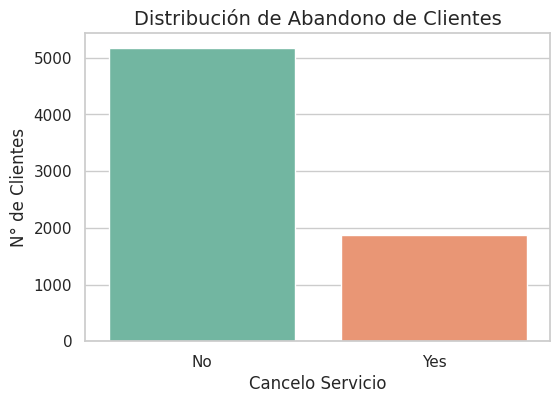

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

plt.figure(figsize=(6, 4))
sns.countplot(data=df_columnas, x='Churn', hue='Churn', palette='Set2')
plt.title('Distribución de Abandono de Clientes', fontsize=14)
plt.xlabel('Cancelo Servicio', fontsize=12)
plt.ylabel('N° de Clientes', fontsize=12)
plt.show()

plt.show()

In [13]:

df_columnas['Charges_Day'] = df_columnas['Charges_Monthly'] / 30
df_columnas

/tmp/ipykernel_144/2833390673.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_columnas['Charges_Day'] = df_columnas['Charges_Monthly'] / 30


,customerID,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Charges_Monthly,Charges_Total,Charges_Day
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,No,Yes,Yes,No,One year,Yes,Mailed check,65.60,593.30,2.186667
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,Yes,Month-to-month,No,Mailed check,59.90,542.40,1.996667
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.90,280.85,2.463333
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.00,1237.85,3.266667
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.90,267.40,2.796667
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7262,9987-LUTYD,No,Female,0,No,No,13,Yes,No,DSL,...,No,Yes,No,No,One year,No,Mailed check,55.15,742.90,1.838333
7263,9992-RRAMN,Yes,Male,0,Yes,No,22,Yes,Yes,Fiber optic,...,No,No,No,Yes,Month-to-month,Yes,Electronic check,85.10,1873.70,2.836667
7264,9992-UJOEL,No,Male,0,No,No,2,Yes,No,DSL,...,No,No,No,No,Month-to-month,Yes,Mailed check,50.30,92.75,1.676667
7265,9993-LHIEB,No,Male,0,Yes,Yes,67,Yes,No,DSL,...,Yes,Yes,No,Yes,Two year,No,Mailed check,67.85,4627.65,2.261667


In [14]:
df_columnas.shape

(7043, 22)

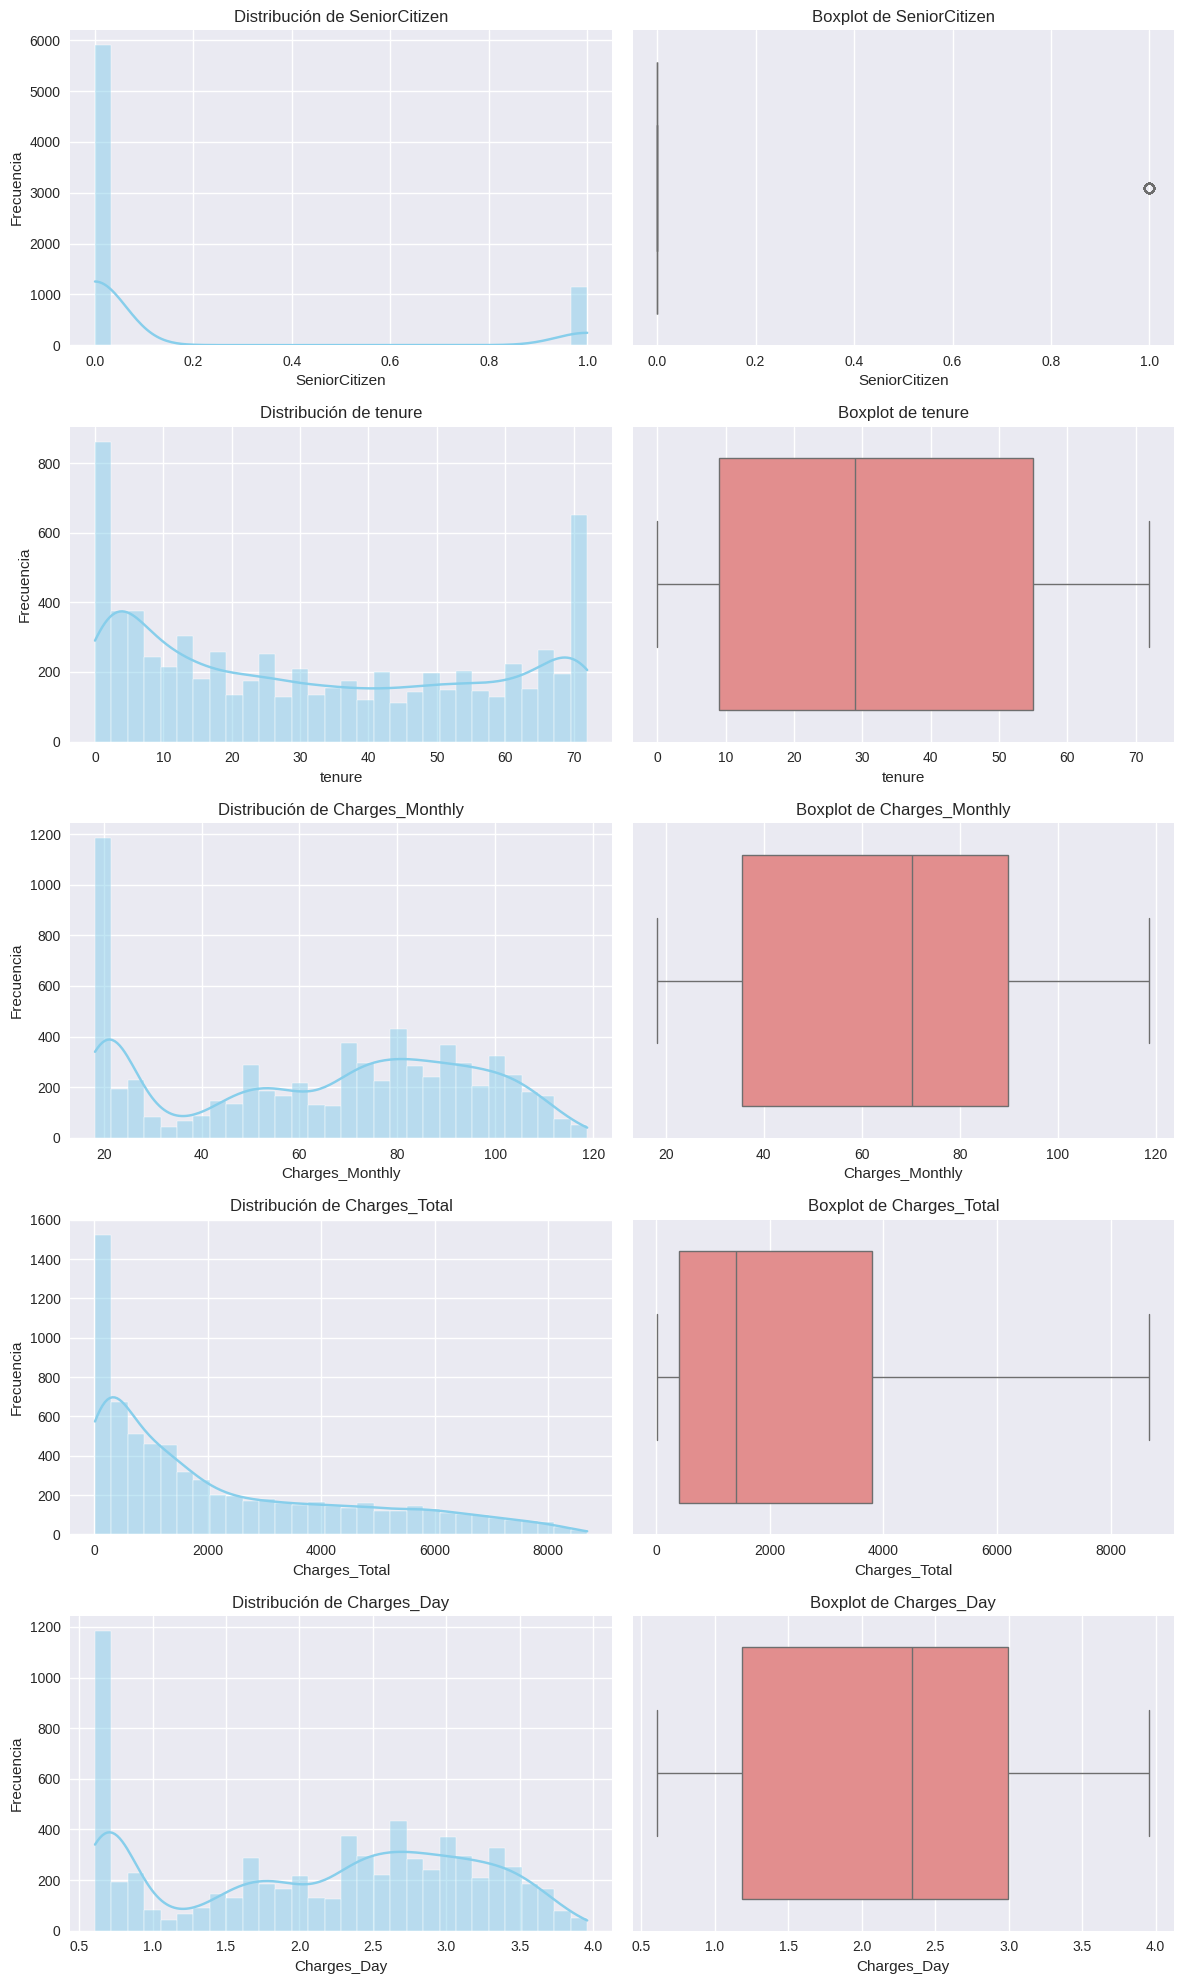

In [15]:

# Lista de variables numéricas
variables = ["SeniorCitizen", "tenure", "Charges_Monthly", "Charges_Total", "Charges_Day"]

# Ajustes generales
plt.style.use("seaborn-v0_8")
fig, axes = plt.subplots(len(variables), 2, figsize=(12, 20))

for i, var in enumerate(variables):
    # Histograma
    sns.histplot(df_columnas[var], bins=30, kde=True, ax=axes[i,0], color="skyblue")
    axes[i,0].set_title(f"Distribución de {var}")
    axes[i,0].set_xlabel(var)
    axes[i,0].set_ylabel("Frecuencia")

    # Boxplot
    sns.boxplot(x=df_columnas[var], ax=axes[i,1], color="lightcoral")
    axes[i,1].set_title(f"Boxplot de {var}")
    axes[i,1].set_xlabel(var)

plt.tight_layout()
plt.show()


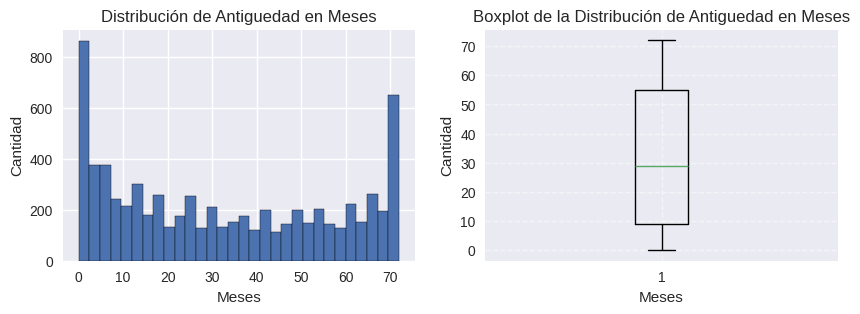

In [16]:
# Crea la Figura y los Ejes. Inicializa un lienzo (fig) y una matriz de Ejes (axs) con 1 fila y 2 columnas. El tamaño de la figura es de 12 con 4 pulgadas.
fig, axs = plt.subplots(1, 2, figsize=(10, 3))

axs[0].hist(df_columnas['tenure'], bins=30, edgecolor="black")
axs[0].set_title('Distribución de Antiguedad en Meses')
axs[0].set_xlabel('Meses')
axs[0].set_ylabel('Cantidad')

axs[1].boxplot(df_columnas['tenure'])
axs[1].set_title('Boxplot de la Distribución de Antiguedad en Meses')
axs[1].set_xlabel('Meses')
axs[1].set_ylabel('Cantidad')
axs[1].grid(True, linestyle='--', alpha=0.5)

plt.show()

In [17]:
# Distribución del género
frecuencia_genero = df_columnas['gender'].value_counts()
porcentaje = df_columnas['gender'].value_counts(normalize=True) * 100

resumen = pd.DataFrame({
    'Total': frecuencia_genero,
    'Porcentaje': porcentaje
})

resumen['Total'] = resumen['Total'].apply(lambda x: f'{x:,.0f}')
resumen['Porcentaje'] = resumen['Porcentaje'].apply(lambda x: f'{x:,.2f} %')

resumen

,Total,Porcentaje
gender,,
Male,"3,555",50.48 %
Female,"3,488",49.52 %


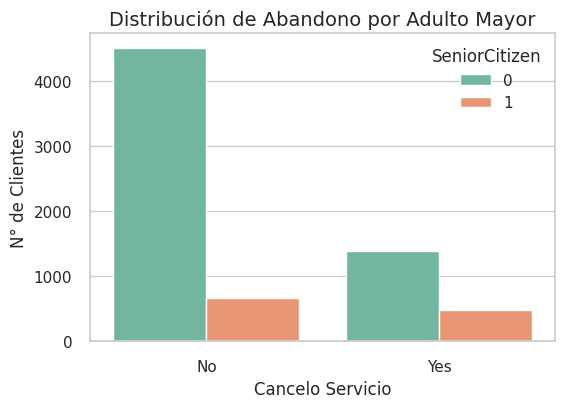

In [18]:
sns.set_theme(style="whitegrid")

plt.figure(figsize=(6, 4))
sns.countplot(data=df_columnas, x='Churn', hue='SeniorCitizen', palette='Set2')
plt.title('Distribución de Abandono por Adulto Mayor', fontsize=14)
plt.xlabel('Cancelo Servicio', fontsize=12)
plt.ylabel('N° de Clientes', fontsize=12)
plt.show()

plt.show()

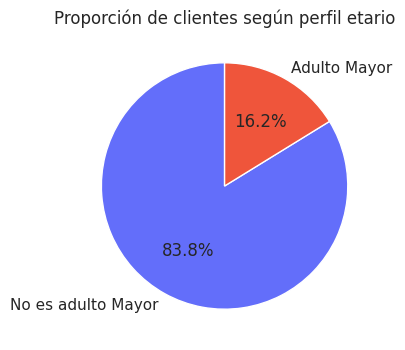

In [19]:

# Distribución de perfil
distribucion_etarea = df_columnas['SeniorCitizen'].value_counts()

# Crear etiquetas legibles
etiquetas = ['No es adulto Mayor' if x == 0 else 'Adulto Mayor' for x in distribucion_etarea.index]

colores = ['#636efa', '#EF553B']

plt.figure(figsize=(4,4))
plt.pie(
    distribucion_etarea,
    autopct='%1.1f%%',
    labels=etiquetas,
    colors=colores,
    startangle=90
)

plt.title('Proporción de clientes según perfil etario')

#plt.legend(etiquetas, title="Categoría", )
plt.show()

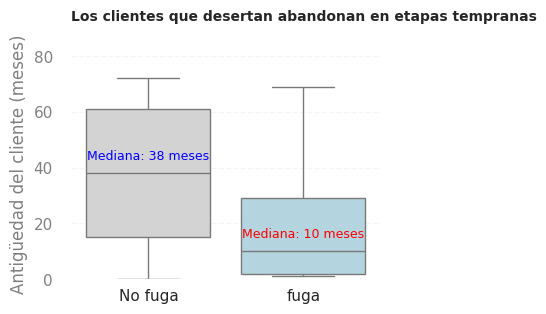

In [23]:
# Serie de tiempo para graficar el Abandono en relación al tiempo de antiguedad

plt.figure(figsize=(4,3))

fuga_clientes_series = df_columnas['Churn'].map({'No': 'No fuga', 'Yes': 'fuga'})

sns.boxplot(
    data=df_columnas,
    x=fuga_clientes_series,
    y='tenure',
    hue=fuga_clientes_series,
    palette={'No fuga': 'lightgray', 'fuga': 'lightblue'},
    showfliers=False,
    legend=False
)

plt.xticks([0,1], ['No fuga', 'fuga'])

plt.title(
    'Los clientes que desertan abandonan en etapas tempranas',
    fontsize=10,
    weight='bold',
    loc='left',
    pad=20
)

# Get the median values for each group using the temporary series for filtering
median_no_fuga = df_columnas.loc[fuga_clientes_series == 'No fuga', 'tenure'].median()
median_fuga = df_columnas.loc[fuga_clientes_series == 'fuga', 'tenure'].median()

# Set the y-axis limits to ensure text visibility, extending slightly above max tenure
plt.ylim(0, df_columnas['tenure'].max() * 1.15) # Adjusted upper limit for text

# Place text for 'No fuga' (General Median)
plt.text(
    0, median_no_fuga + 5, # Position above the median of 'No fuga' box
    f'Mediana: {int(median_no_fuga)} meses',
    ha='center',
    fontsize=9,
    color='blue'
)

# Place text for 'fuga' (Churned Median)
plt.text(
    1, median_fuga + 5, # Position above the median of 'fuga' box
    f'Mediana: {int(median_fuga)} meses',
    ha='center',
    fontsize=9,
    color='red'
)

plt.ylabel('Antigüedad del cliente (meses)', color='gray')
plt.yticks(color='gray')
plt.tick_params(axis='y', color='lightgray')
plt.tick_params(axis='x', color='lightgray', size=0)
plt.xlabel('')

plt.grid(axis='y', linestyle='--', alpha=0.2)
sns.despine(left=True, bottom=True)

plt.show()

In [26]:


#Análisis a la variable "genero" en relación al Churn"
import plotly.express as px
px.histogram(df_columnas, x = 'gender', text_auto = True, color = 'Churn', barmode = 'group',  title='Distribución Churn de clientes por genero')

In [27]:
max_tenure = df_columnas['tenure'].max()

bins = list(range(0, max_tenure + 3, 8))

# Create labels for the bins
labels = []
for i in range(len(bins) - 1):
    if bins[i+1] > max_tenure:
        labels.append(f'{bins[i]+1}-{max_tenure} meses')
    else:
        labels.append(f'{bins[i]+1}-{bins[i+1]} meses')

# Create the 'tiempo_contrato_intervalo' as a temporary Series, not adding it to df
tiempo_contrato_intervalo_temp = pd.cut(df_columnas['tenure'], bins=bins, labels=labels, right=True, include_lowest=True)

# Use this temporary Series in the groupby operation
churn_rate_by_tenure_interval = df.groupby(tiempo_contrato_intervalo_temp, observed=False)['Churn'].value_counts(normalize=True).unstack()
churn_rate_by_tenure_interval['Yes'] = churn_rate_by_tenure_interval['Yes'] * 100 # Convert to percentage
churn_rate_by_tenure_interval = churn_rate_by_tenure_interval.reset_index()
churn_rate_by_tenure_interval.rename(columns={'tiempo_contrato': 'tiempo_contrato_intervalo'}, inplace=True)

fig = px.line(
    churn_rate_by_tenure_interval,
    x='tenure',
    y='Yes',
    title='Tasa de Abandono por Tramos de Antiguedad',
    labels={'tiempo_contrato_intervalo': 'Tiempo de Contrato (intervalos)', 'Sí': 'Tasa de Churn (%)'},
    text='Yes'
)

fig.update_traces(texttemplate='%{text:.2f}%', textposition='top center')
fig.update_layout(uniformtext_minsize=8, uniformtext_mode='hide')
fig.show()